In [1]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import geopandas as gpd
import xarray as xr

In [2]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/Met/WIND_data.csv'

# Read the CSV file into a pandas DataFrame
Wind = pd.read_csv(csv_file_path, sep = ',', skiprows=0)
Wind['Sample Measurement'] = Wind.apply(lambda row: row['MDL'] / 2 * row['Sample Measurement'] if row['Sample Measurement'] < row['MDL'] else row['Sample Measurement'], axis=1)
#Wind['Time Local'] = pd.to_datetime(Wind['Time Local'], format='%H:%M').dt.time
Wind['Timestamp'] = pd.to_datetime(Wind['Date Local'] + ' ' + Wind['Time Local'])
columns_of_interest = ['Date Local', 'State Code', 'Units of Measure', 'Site Num', 'Latitude', 'Longitude', 'Timestamp', 'Sample Measurement', 'MDL']
Windy = Wind[columns_of_interest]
Windy



,Date Local,State Code,Units of Measure,Site Num,Latitude,Longitude,Timestamp,Sample Measurement,MDL
0,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 00:00:00,5.2,0.1
1,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 01:00:00,4.3,0.1
2,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 02:00:00,6.2,0.1
3,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 03:00:00,8.9,0.1
4,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 04:00:00,8.7,0.1
...,...,...,...,...,...,...,...,...,...
8020902,2022-12-31,4,Degrees Compass,1113,32.251843,-110.965293,2022-12-31 19:00:00,135.0,1.0
8020903,2022-12-31,4,Degrees Compass,1113,32.251843,-110.965293,2022-12-31 20:00:00,116.0,1.0
8020904,2022-12-31,4,Degrees Compass,1113,32.251843,-110.965293,2022-12-31 21:00:00,100.0,1.0
8020905,2022-12-31,4,Degrees Compass,1113,32.251843,-110.965293,2022-12-31 22:00:00,122.0,1.0


In [3]:
Winds = Windy[Windy['Units of Measure'] == 'Knots']
Winds['Sample Measurement'] = Winds['Sample Measurement'] * 0.514444
Winds

,Date Local,State Code,Units of Measure,Site Num,Latitude,Longitude,Timestamp,Sample Measurement,MDL
0,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 00:00:00,2.675109,0.1
1,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 01:00:00,2.212109,0.1
2,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 02:00:00,3.189553,0.1
3,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 03:00:00,4.578552,0.1
4,2010-01-01,4,Knots,8001,32.009410,-109.389060,2010-01-01 04:00:00,4.475663,0.1
...,...,...,...,...,...,...,...,...,...
8012144,2022-12-31,4,Knots,1113,32.251843,-110.965293,2022-12-31 19:00:00,1.286110,0.1
8012145,2022-12-31,4,Knots,1113,32.251843,-110.965293,2022-12-31 20:00:00,1.851998,0.1
8012146,2022-12-31,4,Knots,1113,32.251843,-110.965293,2022-12-31 21:00:00,2.572220,0.1
8012147,2022-12-31,4,Knots,1113,32.251843,-110.965293,2022-12-31 22:00:00,1.697665,0.1


In [4]:
Winded = Windy[Windy['Units of Measure'] == 'Degrees Compass']
Winded

,Date Local,State Code,Units of Measure,Site Num,Latitude,Longitude,Timestamp,Sample Measurement,MDL
8698,2010-01-01,4,Degrees Compass,8001,32.009410,-109.389060,2010-01-01 00:00:00,104.0,0.1
8699,2010-01-01,4,Degrees Compass,8001,32.009410,-109.389060,2010-01-01 01:00:00,84.0,0.1
8700,2010-01-01,4,Degrees Compass,8001,32.009410,-109.389060,2010-01-01 02:00:00,102.0,0.1
8701,2010-01-01,4,Degrees Compass,8001,32.009410,-109.389060,2010-01-01 03:00:00,108.0,0.1
8702,2010-01-01,4,Degrees Compass,8001,32.009410,-109.389060,2010-01-01 04:00:00,98.0,0.1
...,...,...,...,...,...,...,...,...,...
8020902,2022-12-31,4,Degrees Compass,1113,32.251843,-110.965293,2022-12-31 19:00:00,135.0,1.0
8020903,2022-12-31,4,Degrees Compass,1113,32.251843,-110.965293,2022-12-31 20:00:00,116.0,1.0
8020904,2022-12-31,4,Degrees Compass,1113,32.251843,-110.965293,2022-12-31 21:00:00,100.0,1.0
8020905,2022-12-31,4,Degrees Compass,1113,32.251843,-110.965293,2022-12-31 22:00:00,122.0,1.0


In [5]:
locations = {
    'Children\'s Park': (-110.9823, -110.9823, 32.29515, 32.29515),
    'Green Valley': (-110.99644, -110.99644, 31.87952,  31.87952),
    'Coach Line': (-111.12716, -111.12716, 32.38082, 32.38082),
    'Rose Elementary': (-110.980134, -110.980134, 32.172995,  32.172995),
    'Fairgrounds': (-110.774357, -110.774357, 32.04767,  32.04767),
    'Tangerine': (-111.06352, -111.06352, 32.425261,  32.425261),
    'Craycroft': (-110.878067, -110.878067, 32.204411,  32.204411),
    'Saguaro National Park': (-110.737116, -110.737116, 32.174538,  32.174538)
}


def extract_locatins(data, locations):
    extracted_data = {}
    
    # Iterate through locations
    for location, (min_long, max_long, min_lat, max_lat) in locations.items():
        # Filter data for the location within the specified season
        data_location = data[(data['Longitude'] >= min_long) & (data['Longitude'] <= max_long) & (data['Latitude'] >= min_lat) & (data['Latitude'] <= max_lat)]
        
        # Store the extracted data in the dictionary
        extracted_data[location] = data_location
    
    return extracted_data


In [6]:
extracted_data = extract_locatins(Winds, locations)
extracted_dir = extract_locatins(Winded, locations)
extracted_data


{"Children's Park":          Date Local  State Code Units of Measure  Site Num  Latitude   
 419243   2010-10-01           4            Knots      1028  32.29515  \
 419244   2010-10-01           4            Knots      1028  32.29515   
 419245   2010-10-01           4            Knots      1028  32.29515   
 419246   2010-10-01           4            Knots      1028  32.29515   
 419247   2010-10-01           4            Knots      1028  32.29515   
 ...             ...         ...              ...       ...       ...   
 7933927  2022-12-31           4            Knots      1028  32.29515   
 7933928  2022-12-31           4            Knots      1028  32.29515   
 7933929  2022-12-31           4            Knots      1028  32.29515   
 7933930  2022-12-31           4            Knots      1028  32.29515   
 7933931  2022-12-31           4            Knots      1028  32.29515   
 
          Longitude           Timestamp  Sample Measurement  MDL  
 419243   -110.9823 2010-10-01 00:00

In [7]:
extracted_dir

{"Children's Park":          Date Local  State Code Units of Measure  Site Num  Latitude   
 421363   2010-10-01           4  Degrees Compass      1028  32.29515  \
 421364   2010-10-01           4  Degrees Compass      1028  32.29515   
 421365   2010-10-01           4  Degrees Compass      1028  32.29515   
 421366   2010-10-01           4  Degrees Compass      1028  32.29515   
 421367   2010-10-01           4  Degrees Compass      1028  32.29515   
 ...             ...         ...              ...       ...       ...   
 7942599  2022-12-31           4  Degrees Compass      1028  32.29515   
 7942600  2022-12-31           4  Degrees Compass      1028  32.29515   
 7942601  2022-12-31           4  Degrees Compass      1028  32.29515   
 7942602  2022-12-31           4  Degrees Compass      1028  32.29515   
 7942603  2022-12-31           4  Degrees Compass      1028  32.29515   
 
          Longitude           Timestamp  Sample Measurement  MDL  
 421363   -110.9823 2010-10-01 00:00

In [8]:
# Function to synchronize two dictionaries of DataFrames based on common Timestamps for each location
def synchronize_dicts_by_timestamp(dict1, dict2):
    # New dictionaries to hold synchronized DataFrames
    dict1_synced = {}
    dict2_synced = {}

    # Iterate over each location in the dictionaries
    for location in dict1:
        if location in dict2:
            # Extract the DataFrames for the current location
            df1 = dict1[location]
            df2 = dict2[location]

            # Find common timestamps between the two DataFrames
            common_timestamps = df1['Timestamp'].drop_duplicates().isin(df2['Timestamp']).values
            
            # Filter both DataFrames based on these common timestamps
            df1_filtered = df1[df1['Timestamp'].isin(df2['Timestamp'])].reset_index(drop=True)
            df2_filtered = df2[df2['Timestamp'].isin(df1['Timestamp'])].reset_index(drop=True)
            
            # Ensure both DataFrames have the same length by truncating to the minimum length
            min_length = min(len(df1_filtered), len(df2_filtered))
            dict1_synced[location] = df1_filtered[:min_length]
            dict2_synced[location] = df2_filtered[:min_length]

    return dict1_synced, dict2_synced

# Usage Example
# Assuming day_speed_data and day_dir_data are dictionaries containing DataFrames for each location
day_speed_data_synced, day_dir_data_synced = synchronize_dicts_by_timestamp(extracted_data, extracted_dir)


In [9]:
day_speed_data_synced

{"Children's Park":         Date Local  State Code Units of Measure  Site Num  Latitude   
 0       2010-10-01           4            Knots      1028  32.29515  \
 1       2010-10-01           4            Knots      1028  32.29515   
 2       2010-10-01           4            Knots      1028  32.29515   
 3       2010-10-01           4            Knots      1028  32.29515   
 4       2010-10-01           4            Knots      1028  32.29515   
 ...            ...         ...              ...       ...       ...   
 106397  2022-12-31           4            Knots      1028  32.29515   
 106398  2022-12-31           4            Knots      1028  32.29515   
 106399  2022-12-31           4            Knots      1028  32.29515   
 106400  2022-12-31           4            Knots      1028  32.29515   
 106401  2022-12-31           4            Knots      1028  32.29515   
 
         Longitude           Timestamp  Sample Measurement  MDL  
 0       -110.9823 2010-10-01 00:00:00           

In [10]:
day_dir_data_synced

{"Children's Park":         Date Local  State Code Units of Measure  Site Num  Latitude   
 0       2010-10-01           4  Degrees Compass      1028  32.29515  \
 1       2010-10-01           4  Degrees Compass      1028  32.29515   
 2       2010-10-01           4  Degrees Compass      1028  32.29515   
 3       2010-10-01           4  Degrees Compass      1028  32.29515   
 4       2010-10-01           4  Degrees Compass      1028  32.29515   
 ...            ...         ...              ...       ...       ...   
 106397  2022-12-31           4  Degrees Compass      1028  32.29515   
 106398  2022-12-31           4  Degrees Compass      1028  32.29515   
 106399  2022-12-31           4  Degrees Compass      1028  32.29515   
 106400  2022-12-31           4  Degrees Compass      1028  32.29515   
 106401  2022-12-31           4  Degrees Compass      1028  32.29515   
 
         Longitude           Timestamp  Sample Measurement  MDL  
 0       -110.9823 2010-10-01 00:00:00           

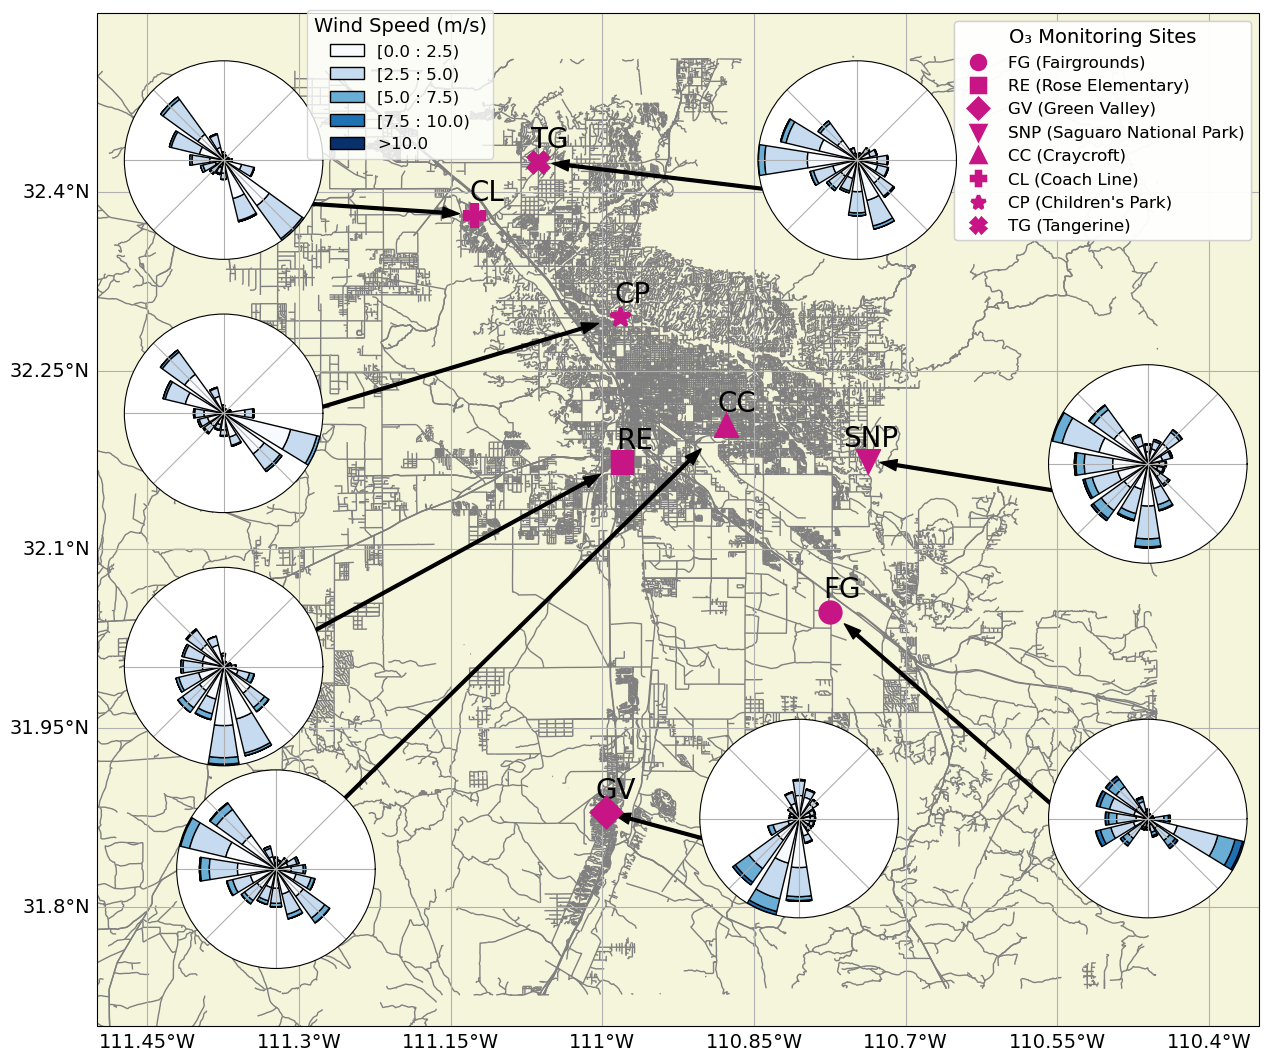

In [11]:
from windrose import WindroseAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# File path for the Pima County shapefile
Pimaa = "C:/Users/taiwoajayi/OneDrive - University of Arizona/Arizona_ozone/Ozone/tl_2023_04019_roads.shp"
gdf_pima = gpd.read_file(Pimaa)

# Abbreviations for study locations
abbreviations = {
    'Fairgrounds': 'FG',
    'Rose Elementary': 'RE',
    'Green Valley': 'GV',
    'Saguaro National Park': 'SNP',
    'Craycroft': 'CC',
    'Coach Line': 'CL',
    'Children\'s Park': 'CP',
    'Tangerine': 'TG'
}

markers = {
    'Fairgrounds': 'o',       # Circle
    'Rose Elementary': 's',   # Square
    'Green Valley': 'D',      # Diamond
    'Saguaro National Park': 'v',      # Downward triangle
    'Craycroft': '^',         # Upward triangle
    'Coach Line': 'P',        # Plus sign
    'Children\'s Park': '*',    # Star
    'Tangerine': 'X'          # X symbol
}

# Function to split day and night data
def split_day_night(dataframe, day_start=6, day_end=18):
    """
    Split a DataFrame into day and night DataFrames based on the Timestamp column.
    """
    dataframe['Hour'] = dataframe['Timestamp'].dt.hour
    day_df = dataframe[(dataframe['Hour'] >= day_start) & (dataframe['Hour'] < day_end)]
    night_df = dataframe[(dataframe['Hour'] < day_start) | (dataframe['Hour'] >= day_end)]
    dataframe.drop(columns=['Hour'], inplace=True)  # Clean up added 'Hour' column
    return day_df, night_df

# Function to plot each wind rose
def plot_windrose(ax, ws, wd, show_legend=False):
    bins = [0, 2.5, 5, 7.5, 10]
    bin_labels = ["0-2.5 m/s", "2.5-5 m/s", "5-7.5 m/s", "7.5-10 m/s", ">10 m/s"]

    # Create the windrose plot using WindroseAxes from the windrose package
    ax.bar(wd, ws, bins=bins, nsector=16, opening=0.8, edgecolor='black', cmap=plt.cm.Blues)
    
    # Remove radial ticks (remove the numbers inside the circle)
    ax.set_yticks([])
    
    # Remove directional labels (N, NE, etc.)
    ax.set_xticklabels([])

    if show_legend:
        # Get handles and labels from the windrose plot
        handles, _ = ax.get_legend_handles_labels()
        # Set custom legend labels manually, avoiding any automatic formatting
        ax.legend(handles=handles, labels=bin_labels, title="Wind Speed (m/s)", loc='best', fontsize=12, title_fontsize=14,  bbox_to_anchor=(1.90, 1.3))

# Main plotting function with wind rose insets on a map
def plot_wind_roses_on_map(speed_data, direction_data, gdf, title):
    fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([-111.5, -110.35, 31.7, 32.55], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='#f5f5dc')
    ax.add_feature(cfeature.STATES, edgecolor='black')

    # Increase map grid labels size
    gl = ax.gridlines(draw_labels=True)
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    gl.xlabels_top = False
    gl.ylabels_right = False

    # Plot the Pima shapefile
    gdf.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=1, zorder=1, transform=ccrs.PlateCarree())

    # Add the study locations with labels
    study_legend_elements = []
    for location, abbreviation in abbreviations.items():
        lat = extracted_data[location]['Latitude'].iloc[0]
        lon = extracted_data[location]['Longitude'].iloc[0]
        marker = markers[location]
        ax.plot(lon, lat, marker=marker, markerfacecolor='mediumvioletred', markeredgecolor='mediumvioletred', markeredgewidth=2.5, markersize=15, transform=ccrs.PlateCarree(), zorder=50)
        ax.text(lon + 0.03, lat + 0.03, abbreviation, transform=ccrs.PlateCarree(), fontsize=20, verticalalignment='top', horizontalalignment='right', color='k')
        study_legend_elements.append(Line2D([0], [0], marker=marker, label=f"{abbreviation} ({location})", markerfacecolor='mediumvioletred', markeredgecolor='mediumvioletred', markeredgewidth=2.5, markersize=10, linestyle='None'))

    # Add the study locations legend
    study_legend = ax.legend(handles=study_legend_elements, loc='upper right', fontsize=12, title="O₃ Monitoring Sites", title_fontsize=14, frameon=True)
    ax.add_artist(study_legend)

    # Define positions for each wind rose inset around the map
    inset_positions = {
        'Tangerine': (0.55, 0.75),  # Upper right
        'Coach Line': (0.005, 0.75),  # Left
        'Children\'s Park': (0.005, 0.50),  # Center
        'Craycroft': (0.05, 0.05),  # Center right
        'Rose Elementary': (0.005, 0.25),  # Left of CC
        'Saguaro National Park': (0.8, 0.45),  # Right of CC
        'Fairgrounds': (0.8, 0.1),  # Bottom right
        'Green Valley': (0.5, 0.1)  # Bottom left
    }

    # Add windrose plots as insets and arrows pointing to locations
    for location in speed_data:
        speed_df = speed_data[location]
        direction_df = direction_data[location]

        if speed_df.empty or direction_df.empty:
            continue  # Skip if no data for the location

        abbreviation = abbreviations.get(location, location)
        wind_speed = speed_df['Sample Measurement'].values
        wind_direction = direction_df['Sample Measurement'].values

        # Ensure wind_speed and wind_direction have the same length
        min_len = min(len(wind_speed), len(wind_direction))
        if min_len == 0:
            continue  # Skip if either array is empty
        wind_speed = wind_speed[:min_len]
        wind_direction = wind_direction[:min_len]

        # Position based on the predefined dictionary
        inset_x, inset_y = inset_positions.get(location, (0.5, 0.5))  # Default position if not specified

        # Create WindroseAxes inset for wind rose plot
        inset_ax = inset_axes(ax, width="140%", height="140%", loc=3, bbox_to_anchor=(inset_x, inset_y, 0.14, 0.14),
                              bbox_transform=ax.transAxes, axes_class=WindroseAxes)
        plot_windrose(inset_ax, wind_speed, wind_direction, show_legend=(location == "Coach Line"))
        #inset_ax.set_title(abbreviation, fontsize=14, pad=5, color='k')

        # Draw arrow from windrose inset to the black dot location
        lat = extracted_data[location]['Latitude'].iloc[0]
        lon = extracted_data[location]['Longitude'].iloc[0]
        ax.annotate(
            '', xy=(lon, lat), xycoords='data',
            xytext=(inset_x + 0.07, inset_y + 0.07), textcoords='axes fraction',
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            transform=ccrs.PlateCarree()
        )

    plt.suptitle(title, fontsize=20, y=0.85)  # Move title above the map
    plt.show()

# Prepare data for plotting
day_speed_data = {}
day_dir_data = {}
night_speed_data = {}
night_dir_data = {}

# Loop through each location to split and prepare day/night data
for location in extracted_data:
    speed_df = extracted_data[location]
    direction_df = extracted_dir[location]

    speed_df['Timestamp'] = pd.to_datetime(speed_df['Timestamp'])
    direction_df['Timestamp'] = pd.to_datetime(direction_df['Timestamp'])

    # Split data into day and night
    day_speed, night_speed = split_day_night(speed_df)
    day_dir, night_dir = split_day_night(direction_df)

    # Filter for valid measurements only
    day_speed_data[location] = day_speed.dropna(subset=['Sample Measurement'])
    day_dir_data[location] = day_dir.dropna(subset=['Sample Measurement'])
    night_speed_data[location] = night_speed.dropna(subset=['Sample Measurement'])
    night_dir_data[location] = night_dir.dropna(subset=['Sample Measurement'])

# Plot day wind roses on the map with the legend on Coach Line only
plot_wind_roses_on_map(day_speed_data, day_dir_data, gdf_pima, '')


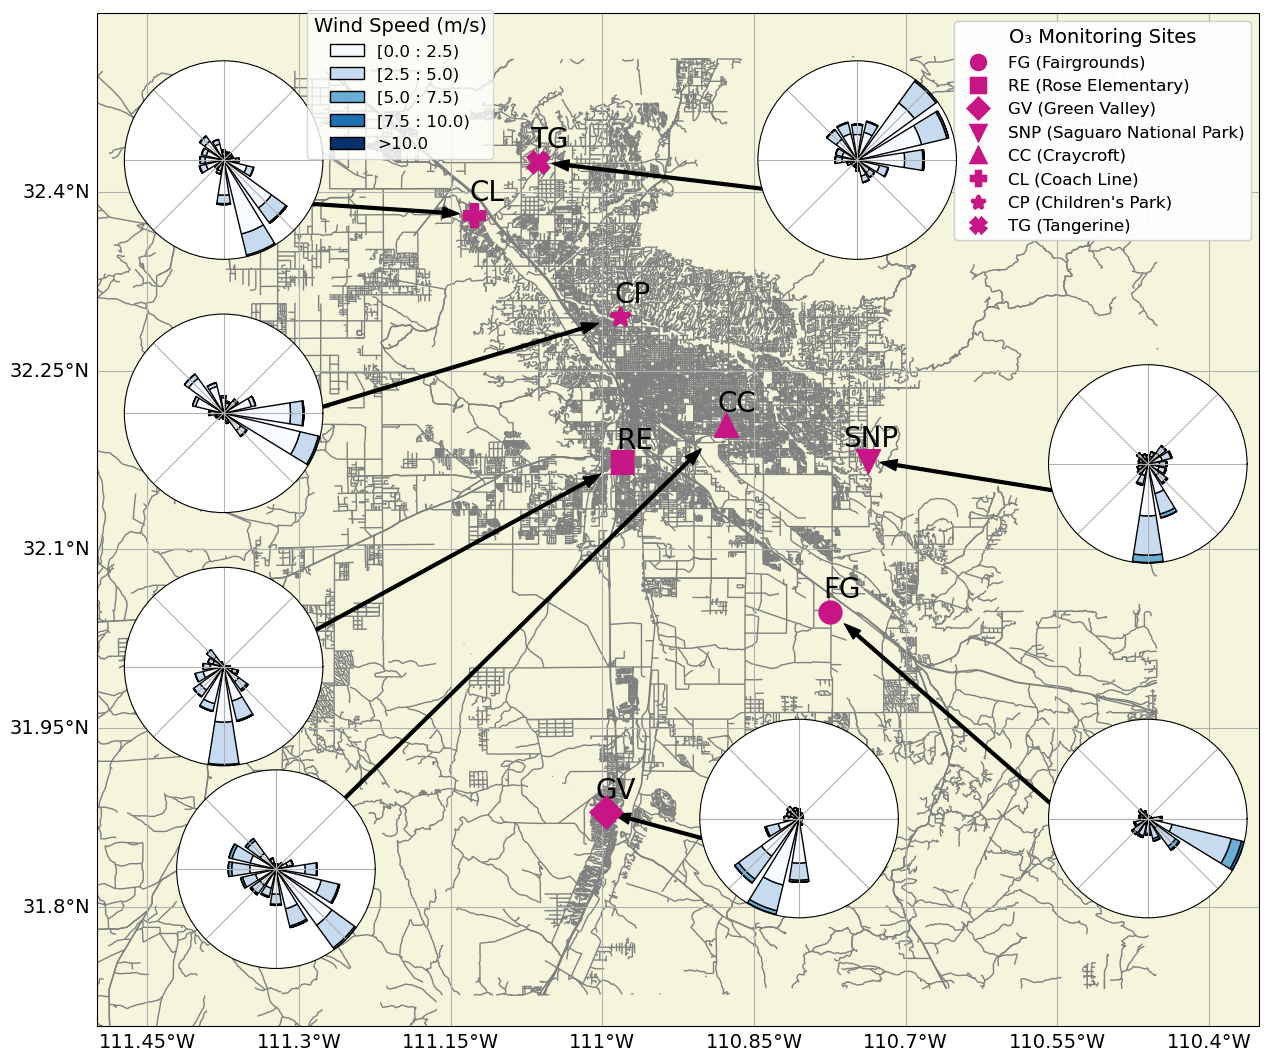

In [12]:
plot_wind_roses_on_map(night_speed_data, night_dir_data, gdf_pima, '')